In [1]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/49_Setting_Env_Variables.ipynb

Successfully set WORKSPACE_CDR to: wb-silky-artichoke-2408.C2024Q3R9
Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: NOT FOUND
WORKSPACE_TEMP_BUCKET: NOT FOUND
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
prep_C2024Q3R9 BQ_DATASET
rw-migration-aou-rw-f7a4d148 GCS_BUCKET
GOOGLE_CLOUD_PROJECT = wb-perky-cabbage-8342
WORKSPACE_BUCKET = None
wb-silky-artichoke-2408.C2024Q3R9



In [2]:
import pandas_gbq
import pandas as pd
import numpy as np

CURRENT_DATASET = %env WORKSPACE_CDR
CURRENT_DATASET

'wb-silky-artichoke-2408.C2024Q3R9'

In [7]:
#### UNCOMMENT & RUN THIS IN YOUR MIGRATED WORKSPACE AND INPUT YOUR MIGRATED BUCKET PATH ####
WORKSPACE_BUCKET = "gs://{rw-migration-aou-rw-f7a4d148}"

In [8]:
#### UNCOMMENT & RUN THIS IN YOUR MIGRATED WORKSPACE TO CHECK FOR FILES IN YOUR BUCKET ####
!gcloud storage ls {WORKSPACE_BUCKET}

ERROR: (gcloud.storage.ls) HTTPError 404: The specified bucket does not exist. This command is authenticated as pet-2766430754533474dc47a@wb-perky-cabbage-8342.iam.gserviceaccount.com which is the active account specified by the [core/account] property.


# Librairy

In [1]:
%load_ext google.cloud.bigquery

import os
import dateutil
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import date
from datetime import datetime
from IPython.display import display, HTML

/opt/conda/envs/jupyter/lib/python3.12/site-packages/google/cloud/bigquery/__init__.py:239: FutureWarning: %load_ext google.cloud.bigquery is deprecated. Install bigquery-magics package and use `%load_ext bigquery_magics`, instead.
  warnings.warn(


# Toutes les femmes ayant eu un cancer du sein (sans contrainte de suivi ou d'inclusion)

In [2]:
DATASET = os.environ["WORKSPACE_CDR"]

sql = f"""
WITH enrollment AS (
  -- Date administrative d'inclusion = 1ère date du module "Consent PII"
  SELECT
    o.person_id,
    MIN(o.observation_date) AS inclusion_date
  FROM `{DATASET}.concept` c
  JOIN `{DATASET}.concept_ancestor` ca
    ON ca.ancestor_concept_id = c.concept_id
  JOIN `{DATASET}.observation` o
    ON o.observation_concept_id = ca.descendant_concept_id
  WHERE c.concept_name = 'Consent PII'
    AND c.concept_class_id = 'Module'
  GROUP BY o.person_id
),

breast_cancer_concepts AS (
  -- Cancer du sein (4157332 + descendants via Dataset Builder / cb_criteria)
  SELECT DISTINCT c.concept_id
  FROM `{DATASET}.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `{DATASET}.cb_criteria` cr
    WHERE cr.concept_id IN (4157332)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

women AS (
  SELECT person_id, birth_datetime
  FROM `{DATASET}.person`
  WHERE gender_concept_id = 45878463  -- Female
),

bc_any AS (
  -- Toutes les femmes qui ont au moins 1 occurrence de BC (même si date manquante)
  SELECT DISTINCT co.person_id
  FROM `{DATASET}.condition_occurrence` co
  JOIN breast_cancer_concepts bc
    ON bc.concept_id = co.condition_concept_id
  JOIN women w
    ON w.person_id = co.person_id
),

bc_dates AS (
  -- Résume les dates : 1ère date dispo + indicateurs de qualité
  SELECT
    co.person_id,
    COUNT(*) AS n_bc_rows,
    SUM(CASE WHEN co.condition_start_date IS NULL THEN 1 ELSE 0 END) AS n_bc_rows_missing_date,
    MIN(co.condition_start_date) AS first_bc_date  -- MIN ignore les NULL
  FROM `{DATASET}.condition_occurrence` co
  JOIN breast_cancer_concepts bc
    ON bc.concept_id = co.condition_concept_id
  GROUP BY co.person_id
)

SELECT
  w.person_id,
  w.birth_datetime AS date_of_birth,
  en.inclusion_date,
  bd.first_bc_date,
  bd.n_bc_rows,
  bd.n_bc_rows_missing_date,

  -- Flags "problème"
  (en.inclusion_date IS NULL) AS missing_inclusion_date,
  (bd.first_bc_date IS NULL) AS missing_bc_date,
  (en.inclusion_date IS NOT NULL AND bd.first_bc_date IS NOT NULL AND bd.first_bc_date <= en.inclusion_date) AS bc_before_or_on_inclusion,

  -- Pour lecture facile
  CASE
    WHEN en.inclusion_date IS NULL AND bd.first_bc_date IS NULL THEN 'MISSING_INCLUSION_AND_BC_DATE'
    WHEN en.inclusion_date IS NULL THEN 'MISSING_INCLUSION_DATE'
    WHEN bd.first_bc_date IS NULL THEN 'MISSING_BC_DATE'
    WHEN bd.first_bc_date <= en.inclusion_date THEN 'BC_BEFORE_OR_ON_INCLUSION'
    ELSE 'OK_BC_AFTER_INCLUSION'
  END AS issue_category

FROM bc_any a
JOIN women w
  ON w.person_id = a.person_id
LEFT JOIN enrollment en
  ON en.person_id = a.person_id
LEFT JOIN bc_dates bd
  ON bd.person_id = a.person_id

-- On ne garde que les cas "problèmes"
WHERE (en.inclusion_date IS NULL)
   OR (bd.first_bc_date IS NULL)
   OR (en.inclusion_date IS NOT NULL AND bd.first_bc_date IS NOT NULL AND bd.first_bc_date <= en.inclusion_date)
"""

df_issues = pd.read_gbq(
    sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

df_issues.head()
df_issues

/tmp/ipykernel_960/298297477.py:102: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_issues = pd.read_gbq(


Downloading:   0%|          |

,person_id,date_of_birth,inclusion_date,first_bc_date,n_bc_rows,n_bc_rows_missing_date,missing_inclusion_date,missing_bc_date,bc_before_or_on_inclusion,issue_category
0,5205693,1983-06-15 00:00:00+00:00,2023-06-23,2019-11-04,16,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
1,7611756,1982-06-15 00:00:00+00:00,2023-05-01,2022-04-21,54,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
2,2364124,1982-06-15 00:00:00+00:00,2022-03-17,2018-07-25,135,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
3,2000175,1986-06-15 00:00:00+00:00,2020-03-06,2010-07-29,48,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
4,8726861,1983-06-15 00:00:00+00:00,2022-03-28,2021-01-25,200,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
...,...,...,...,...,...,...,...,...,...,...
9950,4608995,1981-06-15 00:00:00+00:00,2022-03-08,2021-08-09,21,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
9951,9062404,1981-06-15 00:00:00+00:00,2022-12-12,2017-06-29,1,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
9952,9719519,1981-06-15 00:00:00+00:00,2022-02-18,2015-08-07,138,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION
9953,2275672,1981-06-15 00:00:00+00:00,2019-03-05,2017-02-07,3,0,False,False,True,BC_BEFORE_OR_ON_INCLUSION


# Femmes sans cancer avant inclusion et cancer du sein apres (sans contrainte 5 ans)

In [3]:
# Women with breast cancer after inclusion (any time), excluding any prior cancer before inclusion
dataset_breast_cancer_after_inclusion_sql = """
WITH enrollment AS (
  -- Date administrative d'inclusion = 1ère date du module "Consent PII"
  SELECT
    o.person_id,
    MIN(o.observation_date) AS inclusion_date
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.concept` c
  JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept_ancestor` ca
    ON ca.ancestor_concept_id = c.concept_id
  JOIN `""" + os.environ["WORKSPACE_CDR"] + """.observation` o
    ON o.observation_concept_id = ca.descendant_concept_id
  WHERE c.concept_name = 'Consent PII'
    AND c.concept_class_id = 'Module'
  GROUP BY o.person_id
),

breast_cancer_concepts AS (
  -- Cancer du sein (4157332 + descendants via Dataset Builder)
  SELECT DISTINCT c.concept_id
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr
    WHERE cr.concept_id IN (4157332)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

cancer_exclusion_concepts AS (
  -- Tout cancer à exclure (443392 + descendants via Dataset Builder)
  SELECT DISTINCT c.concept_id
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr
    WHERE cr.concept_id IN (443392)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

breast_cancer_after_inclusion AS (
  -- 1er diagnostic de cancer du sein APRÈS inclusion (n'importe quand)
  SELECT
    co.person_id,
    MIN(co.condition_start_date) AS first_breast_cancer_date
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.condition_occurrence` co
  JOIN enrollment en
    ON en.person_id = co.person_id
  JOIN breast_cancer_concepts bc
    ON bc.concept_id = co.condition_concept_id
  WHERE co.condition_start_date IS NOT NULL
    AND co.condition_start_date > en.inclusion_date
  GROUP BY co.person_id
),

prior_cancer AS (
  -- Toute occurrence de cancer (443392 + descendants) AVANT inclusion
  SELECT DISTINCT
    co.person_id
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.condition_occurrence` co
  JOIN enrollment en
    ON en.person_id = co.person_id
  JOIN cancer_exclusion_concepts cc
    ON cc.concept_id = co.condition_concept_id
  WHERE co.condition_start_date IS NOT NULL
    AND co.condition_start_date < en.inclusion_date
)

SELECT
  person.person_id,
  p_gender_concept.concept_name AS gender,
  person.birth_datetime AS date_of_birth,
  p_ethnicity_concept.concept_name AS ethnicity,
  p_self_reported_category_concept.concept_name AS self_reported_category,
  en.inclusion_date,
  bc.first_breast_cancer_date
FROM `""" + os.environ["WORKSPACE_CDR"] + """.person` person
JOIN breast_cancer_after_inclusion bc
  ON bc.person_id = person.person_id
JOIN enrollment en
  ON en.person_id = person.person_id
LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_gender_concept
  ON person.gender_concept_id = p_gender_concept.concept_id
LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_ethnicity_concept
  ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id
LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_self_reported_category_concept
  ON person.self_reported_category_concept_id = p_self_reported_category_concept.concept_id
LEFT JOIN prior_cancer pc
  ON pc.person_id = person.person_id
WHERE person.gender_concept_id = 45878463  -- FEMMES UNIQUEMENT
  AND pc.person_id IS NULL                -- EXCLURE cancer avant inclusion
"""

dataset_breast_cancer_after_inclusion_df = pd.read_gbq(
    dataset_breast_cancer_after_inclusion_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

dataset_breast_cancer_after_inclusion_df

Downloading:   0%|          | 0/1586 [00:00<?, ?rows/s]

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date
0,2211837,Female,1975-06-15 00:00:00+00:00,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-24,2021-10-11
1,1101159,Female,1977-06-15 00:00:00+00:00,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-12-18,2019-03-08
2,9054344,Female,1952-06-15 00:00:00+00:00,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2021-03-15,2021-12-14
3,1181952,Female,1949-06-15 00:00:00+00:00,Not Hispanic or Latino,Asian,2019-10-30,2021-01-07
4,2359864,Female,1958-06-15 00:00:00+00:00,Not Hispanic or Latino,Asian,2019-03-04,2019-08-21
...,...,...,...,...,...,...,...
1581,1506709,Female,1953-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2018-12-04,2022-11-10
1582,3518386,Female,1980-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2019-08-13,2021-06-10
1583,2083810,Female,1948-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2018-05-11,2022-06-06
1584,3428076,Female,1961-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2018-03-21,2018-05-01


In [4]:
# Liste des femmes n'ayant pas eu de cancer avant inclusion et cancer du sein dans les 5 ans après 
list_id_bc_in_all_time = dataset_breast_cancer_after_inclusion_df['person_id'].to_list()

# Femmes n'ayant pas eu de cancer avant inclusion et cancer du sein dans les 5 ans après l'inclusion

In [5]:
# Women with BC within 5 years after inclusion, excluding any prior cancer (443392 + descendants)
dataset_breast_cancer_5y_person_sql = """
WITH enrollment AS (
  -- Date administrative d'inclusion = 1ère date du module "Consent PII"
  SELECT
    o.person_id,
    MIN(o.observation_date) AS inclusion_date
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.concept` c
  JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept_ancestor` ca
    ON ca.ancestor_concept_id = c.concept_id
  JOIN `""" + os.environ["WORKSPACE_CDR"] + """.observation` o
    ON o.observation_concept_id = ca.descendant_concept_id
  WHERE c.concept_name = 'Consent PII'
    AND c.concept_class_id = 'Module'
  GROUP BY o.person_id
),

breast_cancer_concepts AS (
  -- Cancer du sein (4157332 + descendants via Dataset Builder)
  SELECT DISTINCT c.concept_id
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr
    WHERE cr.concept_id IN (4157332)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

cancer_exclusion_concepts AS (
  -- Tout cancer à exclure (443392 + descendants via Dataset Builder)
  SELECT DISTINCT c.concept_id
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr
    WHERE cr.concept_id IN (443392)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

breast_cancer_5y AS (
  -- 1er diagnostic de cancer du sein ≤ 5 ans après inclusion
  SELECT
    co.person_id,
    MIN(co.condition_start_date) AS first_breast_cancer_date
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.condition_occurrence` co
  JOIN enrollment en
    ON en.person_id = co.person_id
  JOIN breast_cancer_concepts bc
    ON bc.concept_id = co.condition_concept_id
  WHERE co.condition_start_date IS NOT NULL
    AND co.condition_start_date > en.inclusion_date
    AND co.condition_start_date <= DATE_ADD(en.inclusion_date, INTERVAL 5 YEAR)
  GROUP BY co.person_id
),

prior_cancer AS (
  -- Toute occurrence de cancer (443392 + descendants) AVANT inclusion
  SELECT DISTINCT
    co.person_id
  FROM `""" + os.environ["WORKSPACE_CDR"] + """.condition_occurrence` co
  JOIN enrollment en
    ON en.person_id = co.person_id
  JOIN cancer_exclusion_concepts cc
    ON cc.concept_id = co.condition_concept_id
  WHERE co.condition_start_date IS NOT NULL
    AND co.condition_start_date < en.inclusion_date
)

SELECT
  person.person_id,
  p_gender_concept.concept_name AS gender,
  person.birth_datetime AS date_of_birth,
  p_ethnicity_concept.concept_name AS ethnicity,
  p_self_reported_category_concept.concept_name AS self_reported_category,
  en.inclusion_date,
  bc5.first_breast_cancer_date
FROM `""" + os.environ["WORKSPACE_CDR"] + """.person` person
JOIN breast_cancer_5y bc5
  ON bc5.person_id = person.person_id
JOIN enrollment en
  ON en.person_id = person.person_id
LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_gender_concept
  ON person.gender_concept_id = p_gender_concept.concept_id
LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_ethnicity_concept
  ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id
LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_self_reported_category_concept
  ON person.self_reported_category_concept_id = p_self_reported_category_concept.concept_id
LEFT JOIN prior_cancer pc
  ON pc.person_id = person.person_id
WHERE person.gender_concept_id = 45878463  -- FEMMES UNIQUEMENT
  AND pc.person_id IS NULL                -- EXCLURE cancer avant inclusion
"""

dataset_breast_cancer_5y_person_df = pd.read_gbq(
    dataset_breast_cancer_5y_person_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

dataset_breast_cancer_5y_person_df


Downloading:   0%|          | 0/1555 [00:00<?, ?rows/s]

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date
0,1159265,Female,1952-06-15 00:00:00+00:00,Not Hispanic or Latino,Black or African American,2019-03-20,2019-08-21
1,1559673,Female,1953-06-15 00:00:00+00:00,Not Hispanic or Latino,Black or African American,2019-01-16,2019-04-16
2,1312515,Female,1954-06-15 00:00:00+00:00,Not Hispanic or Latino,Black or African American,2019-12-18,2022-03-11
3,1293799,Female,1955-06-15 00:00:00+00:00,Not Hispanic or Latino,Black or African American,2019-08-14,2021-11-18
4,3073048,Female,1957-06-15 00:00:00+00:00,Not Hispanic or Latino,Black or African American,2021-05-21,2021-05-26
...,...,...,...,...,...,...,...
1550,2242684,Female,1967-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2019-03-19,2020-03-17
1551,7598359,Female,1967-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2022-02-21,2023-03-30
1552,1872804,Female,1974-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2019-10-02,2020-04-22
1553,2625596,Female,1975-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2019-08-19,2019-11-11


In [6]:
# Liste des femmes n'ayant pas eu de cancer avant inclusion et cancer du sein dans les 5 ans après 
list_id_bc_in_5y = dataset_breast_cancer_5y_person_df['person_id'].to_list()

# Toutes les femmes n'ayant pas eu de cancer avant l'inclusion et cancer du sein sans limite de temps (incluant les 1555 ayant eu un cancer du sein dans les 5 ans apres inclusion)

dataset_women_no_prior_cancer_sql = f"""
WITH enrollment AS (
  -- Date administrative d'inclusion = 1ère date du module "Consent PII"
  SELECT
    o.person_id,
    MIN(o.observation_date) AS inclusion_date
  FROM `{os.environ["WORKSPACE_CDR"]}.concept` c
  JOIN `{os.environ["WORKSPACE_CDR"]}.concept_ancestor` ca
    ON ca.ancestor_concept_id = c.concept_id
  JOIN `{os.environ["WORKSPACE_CDR"]}.observation` o
    ON o.observation_concept_id = ca.descendant_concept_id
  WHERE c.concept_name = 'Consent PII'
    AND c.concept_class_id = 'Module'
  GROUP BY o.person_id
),

cancer_exclusion_concepts AS (
  -- Tout cancer à exclure (443392 + descendants via Dataset Builder)
  SELECT DISTINCT c.concept_id
  FROM `{os.environ["WORKSPACE_CDR"]}.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `{os.environ["WORKSPACE_CDR"]}.cb_criteria` cr
    WHERE cr.concept_id IN (443392)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

prior_cancer AS (
  -- Toute occurrence de cancer (443392 + descendants) AVANT inclusion
  SELECT DISTINCT
    co.person_id
  FROM `{os.environ["WORKSPACE_CDR"]}.condition_occurrence` co
  JOIN enrollment en
    ON en.person_id = co.person_id
  JOIN cancer_exclusion_concepts cc
    ON cc.concept_id = co.condition_concept_id
  WHERE co.condition_start_date IS NOT NULL
    AND co.condition_start_date < en.inclusion_date
)

SELECT
  person.person_id,
  p_gender_concept.concept_name AS gender,
  person.birth_datetime AS date_of_birth,
  p_ethnicity_concept.concept_name AS ethnicity,
  p_self_reported_category_concept.concept_name AS self_reported_category,
  en.inclusion_date
FROM `{os.environ["WORKSPACE_CDR"]}.person` person
JOIN enrollment en
  ON en.person_id = person.person_id
LEFT JOIN `{os.environ["WORKSPACE_CDR"]}.concept` p_gender_concept
  ON person.gender_concept_id = p_gender_concept.concept_id
LEFT JOIN `{os.environ["WORKSPACE_CDR"]}.concept` p_ethnicity_concept
  ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id
LEFT JOIN `{os.environ["WORKSPACE_CDR"]}.concept` p_self_reported_category_concept
  ON person.self_reported_category_concept_id = p_self_reported_category_concept.concept_id
LEFT JOIN prior_cancer pc
  ON pc.person_id = person.person_id
WHERE person.gender_concept_id = 45878463  -- FEMMES UNIQUEMENT
  AND pc.person_id IS NULL                -- EXCLURE cancer avant inclusion
"""

dataset_women_no_prior_cancer_df = pd.read_gbq(
    dataset_women_no_prior_cancer_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

dataset_women_no_prior_cancer_df

In [7]:
dataset_women_no_prior_cancer_sql = f"""
WITH enrollment AS (
  -- Date administrative d'inclusion = 1ère date du module "Consent PII"
  SELECT
    o.person_id,
    MIN(o.observation_date) AS inclusion_date
  FROM `{os.environ["WORKSPACE_CDR"]}.concept` c
  JOIN `{os.environ["WORKSPACE_CDR"]}.concept_ancestor` ca
    ON ca.ancestor_concept_id = c.concept_id
  JOIN `{os.environ["WORKSPACE_CDR"]}.observation` o
    ON o.observation_concept_id = ca.descendant_concept_id
  WHERE c.concept_name = 'Consent PII'
    AND c.concept_class_id = 'Module'
  GROUP BY o.person_id
),

cancer_exclusion_concepts AS (
  -- Tout cancer à exclure (443392 + descendants)
  SELECT DISTINCT c.concept_id
  FROM `{os.environ["WORKSPACE_CDR"]}.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `{os.environ["WORKSPACE_CDR"]}.cb_criteria` cr
    WHERE cr.concept_id IN (443392)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

breast_cancer_concepts AS (
  -- Uniquement Cancer du sein (4157332 + descendants)
  SELECT DISTINCT c.concept_id
  FROM `{os.environ["WORKSPACE_CDR"]}.cb_criteria` c
  JOIN (
    SELECT CAST(cr.id AS STRING) AS id
    FROM `{os.environ["WORKSPACE_CDR"]}.cb_criteria` cr
    WHERE cr.concept_id IN (4157332)
      AND cr.full_text LIKE '%_rank1]%'
  ) a
    ON (c.path LIKE CONCAT('%.', a.id, '.%')
        OR c.path LIKE CONCAT('%.', a.id)
        OR c.path LIKE CONCAT(a.id, '.%')
        OR c.path = a.id)
  WHERE c.is_standard = 1
    AND c.is_selectable = 1
),

prior_cancer AS (
  -- Toute occurrence de cancer AVANT inclusion (pour exclusion)
  SELECT DISTINCT
    co.person_id
  FROM `{os.environ["WORKSPACE_CDR"]}.condition_occurrence` co
  JOIN enrollment en ON en.person_id = co.person_id
  JOIN cancer_exclusion_concepts cc ON cc.concept_id = co.condition_concept_id
  WHERE co.condition_start_date IS NOT NULL
    AND co.condition_start_date < en.inclusion_date
),

first_breast_cancer AS (
  -- 1er diagnostic de cancer du sein APRÈS inclusion (sans limite de 5 ans)
  SELECT
    co.person_id,
    MIN(co.condition_start_date) AS first_breast_cancer_date
  FROM `{os.environ["WORKSPACE_CDR"]}.condition_occurrence` co
  JOIN enrollment en ON en.person_id = co.person_id
  JOIN breast_cancer_concepts bc ON bc.concept_id = co.condition_concept_id
  WHERE co.condition_start_date IS NOT NULL
    AND co.condition_start_date >= en.inclusion_date
  GROUP BY co.person_id
)

SELECT
  person.person_id,
  p_gender_concept.concept_name AS gender,
  person.birth_datetime AS date_of_birth,
  p_ethnicity_concept.concept_name AS ethnicity,
  p_self_reported_category_concept.concept_name AS self_reported_category,
  en.inclusion_date,
  fbc.first_breast_cancer_date
FROM `{os.environ["WORKSPACE_CDR"]}.person` person
JOIN enrollment en
  ON en.person_id = person.person_id
LEFT JOIN first_breast_cancer fbc
  ON fbc.person_id = person.person_id
LEFT JOIN `{os.environ["WORKSPACE_CDR"]}.concept` p_gender_concept
  ON person.gender_concept_id = p_gender_concept.concept_id
LEFT JOIN `{os.environ["WORKSPACE_CDR"]}.concept` p_ethnicity_concept
  ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id
LEFT JOIN `{os.environ["WORKSPACE_CDR"]}.concept` p_self_reported_category_concept
  ON person.self_reported_category_concept_id = p_self_reported_category_concept.concept_id
LEFT JOIN prior_cancer pc
  ON pc.person_id = person.person_id
WHERE person.gender_concept_id = 45878463  -- FEMMES
  AND pc.person_id IS NULL                -- EXCLURE cancer avant inclusion
"""

dataset_women_no_prior_cancer_df = pd.read_gbq(
    dataset_women_no_prior_cancer_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

dataset_women_no_prior_cancer_df.head(5)

Downloading:   0%|          | 0/360886 [00:00<?, ?rows/s]

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date
0,2028403,Female,1934-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2019-11-15,NaT
1,7685408,Female,2002-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2022-11-03,NaT
2,2299281,Female,1937-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2019-03-06,NaT
3,2047635,Female,1941-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2018-11-09,NaT
4,1608049,Female,1939-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2018-10-29,NaT


## Vérification de la présence des 1586 femmes (cancer all time) et des 1555 femmes (cancer < 5 ans)

### Nombre de femmes ayant une date `first_breast_cancer_date`

In [8]:
dataset_women_no_prior_cancer_df['first_breast_cancer_date'].notna().sum()

1588

### Observation des 2 femmes supplémentaires obtenues

In [9]:
dataset_women_no_prior_cancer_df[dataset_women_no_prior_cancer_df['first_breast_cancer_date'].notna() & (~dataset_women_no_prior_cancer_df['person_id'].isin(list_id_bc_in_all_time))]

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date
285,1885647,Female,1940-06-15 00:00:00+00:00,Not Hispanic or Latino,Asian,2020-02-13,2020-02-13
8230,1930111,Female,1930-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2019-01-02,2019-01-02


Les femmes ont une date de premier cancer identique à la date d'inclusion, laissant supposer que le cancer se soit déclaré avant ou éventuellement le jour de l'inclusion... Devons-nous les conserver ? 

### Les 1586 femmes identifiées comme ayant déclarées un cancer du sein après inclusion sont-elles bien présente ? 

In [10]:
dataset_women_no_prior_cancer_df[dataset_women_no_prior_cancer_df['person_id'].isin(list_id_bc_in_all_time)]

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date
67,1070767,Female,1935-06-15 00:00:00+00:00,What Race Ethnicity: Race Ethnicity None Of These,None of these,2018-05-21,2022-06-14
304,8140876,Female,1932-06-15 00:00:00+00:00,Not Hispanic or Latino,Asian,2021-08-16,2023-08-11
710,3229264,Female,1940-06-15 00:00:00+00:00,Not Hispanic or Latino,Middle Eastern or North African,2018-12-05,2019-07-26
1063,2406666,Female,1939-06-15 00:00:00+00:00,Hispanic or Latino,More than one population,2018-01-19,2018-01-26
1353,1956684,Female,1939-06-15 00:00:00+00:00,Not Hispanic or Latino,More than one population,2019-11-20,2019-12-10
...,...,...,...,...,...,...,...
316462,1808027,Female,1992-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2017-12-14,2019-03-19
320029,7985797,Female,1993-06-15 00:00:00+00:00,Not Hispanic or Latino,Black or African American,2023-03-21,2023-05-11
325642,5383506,Female,1994-06-15 00:00:00+00:00,Not Hispanic or Latino,More than one population,2022-03-02,2022-03-17
340163,2437775,Female,1996-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2018-03-14,2018-04-06


### Présence des 1555 femmes identifiées comme ayant déclarées un cancer du seins dans les 5 ans suivant l'inclusion ? 

In [11]:
dataset_women_no_prior_cancer_df[dataset_women_no_prior_cancer_df['person_id'].isin(list_id_bc_in_5y)]

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date
67,1070767,Female,1935-06-15 00:00:00+00:00,What Race Ethnicity: Race Ethnicity None Of These,None of these,2018-05-21,2022-06-14
304,8140876,Female,1932-06-15 00:00:00+00:00,Not Hispanic or Latino,Asian,2021-08-16,2023-08-11
710,3229264,Female,1940-06-15 00:00:00+00:00,Not Hispanic or Latino,Middle Eastern or North African,2018-12-05,2019-07-26
1063,2406666,Female,1939-06-15 00:00:00+00:00,Hispanic or Latino,More than one population,2018-01-19,2018-01-26
1353,1956684,Female,1939-06-15 00:00:00+00:00,Not Hispanic or Latino,More than one population,2019-11-20,2019-12-10
...,...,...,...,...,...,...,...
316462,1808027,Female,1992-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2017-12-14,2019-03-19
320029,7985797,Female,1993-06-15 00:00:00+00:00,Not Hispanic or Latino,Black or African American,2023-03-21,2023-05-11
325642,5383506,Female,1994-06-15 00:00:00+00:00,Not Hispanic or Latino,More than one population,2022-03-02,2022-03-17
340163,2437775,Female,1996-06-15 00:00:00+00:00,Not Hispanic or Latino,White,2018-03-14,2018-04-06


## Variables `datetime` - Treatment & Feature Engineering

In [12]:
df = dataset_women_no_prior_cancer_df.copy()
df.head(5)

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date
0,2028403,Female,1934-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2019-11-15,NaT
1,7685408,Female,2002-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2022-11-03,NaT
2,2299281,Female,1937-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2019-03-06,NaT
3,2047635,Female,1941-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2018-11-09,NaT
4,1608049,Female,1939-06-15 00:00:00+00:00,PMI: Prefer Not To Answer,I prefer not to answer,2018-10-29,NaT


### Conversion des colonnes `date`en format `datetime`

In [13]:
# Convertis et retire le fuseau horaire (UTC) pour date_of_birth et transforme en 'datetime64[ns]'
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce").dt.tz_localize(None).dt.normalize()

df["inclusion_date"] = pd.to_datetime(df["inclusion_date"], errors="coerce")
df["first_breast_cancer_date"] = pd.to_datetime(df["first_breast_cancer_date"], errors="coerce")

### Ajout d'une colonne `delay_days`pour indiquer le temps entre l'inclusion et la déclaration du cancer du sein

In [14]:
# Délai en jours
df["delay_days"] = (df["first_breast_cancer_date"] - df["inclusion_date"]).dt.days

# Délai en années
df["delay_years"] = df["delay_days"] / 365.25

### Ajout d'une colonne catégorie `time_category` pour identifier les cancers du sein déclarés selon l'année

In [15]:
df["time_category"] = pd.cut(
    df["delay_years"],
    bins=[0, 1, 2, 3, 4, 5, np.inf],
    labels=[
        "≤ 1 an",
        "1–2 ans",
        "2–3 ans",
        "3–4 ans",
        "4–5 ans",
        "> 5 ans"
    ],
    right=True
)

### Ajout d'une colonne `age_at_inclusion` pour identifier l'age des individus

In [16]:
# Âge à l’inclusion (années)
df["age_at_inclusion"] = (df["inclusion_date"] - df["date_of_birth"]).dt.days / 365.25

### Ajout d'une colonne `has_bc` pour identifier les personnes ayant eu un cancer dans les 5 après l'inclusion

In [17]:
df['has_bc'] = df['first_breast_cancer_date'].notna().astype(int)

## Détails statistiques

### Date de la dernière déclaration de cancer du sein

In [18]:
most_recent_cancer_date = df["first_breast_cancer_date"].max()
print(most_recent_cancer_date.strftime('%Y-%m-%d'))

2023-09-29


### Délais moyen / médian de déclaration de cancer du sein après inclusion

In [19]:
mean_delay_years = df["delay_years"].mean()
median_delay_years = df["delay_years"].median()

print("Délai de déclaration du cancer du sein après inclusion :")
print("Moyenne :", round(mean_delay_years, 4))
print("Médiane :", round(median_delay_years, 4))

Délai de déclaration du cancer du sein après inclusion :
Moyenne : 1.8592
Médiane : 1.5264


### Répartition des déclarations de cancer du sein par catégorie de temps

In [20]:
time_counts = df["time_category"].value_counts().sort_index()
time_counts

time_category
≤ 1 an     568
1–2 ans    361
2–3 ans    244
3–4 ans    225
4–5 ans    145
> 5 ans     31
Name: count, dtype: int64

### Répartition des individus selon l'ethnie autodéclarée

In [21]:
ethnicity_counts = (df["self_reported_category"].fillna("Unknown").value_counts())
ethnicity_counts

self_reported_category
White                                        193924
What Race Ethnicity: Hispanic                 57786
Black or African American                     54556
More than one population                      28400
Asian                                         12239
None of these                                  3643
American Indian or Alaska Native               3461
PMI: Skip                                      3251
I prefer not to answer                         1677
Middle Eastern or North African                1623
Native Hawaiian or Other Pacific Islander       326
Name: count, dtype: int64

### Analyse des femmes < 40 ans

#### Nombre de femme ayant moins de 40 ans

In [22]:
n_under_40 = (df["age_at_inclusion"] < 40).sum()
n_under_40

124146

#### Répartition des femmes ayant un age < 40 ans selon la catégorie de temps

In [23]:
df[(df['person_id'].isin(list_id_bc_in_5y)) & (df["age_at_inclusion"] < 40)].value_counts('time_category')

time_category
≤ 1 an     35
1–2 ans    20
3–4 ans    15
2–3 ans    11
4–5 ans     7
> 5 ans     0
Name: count, dtype: int64

#### Distribution de `age_at_inclusion` pour les femmes < 40 ans

<Axes: >

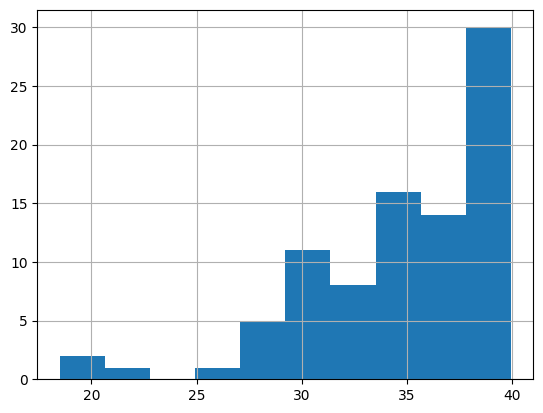

In [24]:
df[(df['person_id'].isin(list_id_bc_in_5y)) & (df["age_at_inclusion"] < 40)]["age_at_inclusion"].hist()

### Répartition de l'apprition du cancer du sein (dans les 5ans) selon l'année d'inclusion

In [25]:
df[df['person_id'].isin(list_id_bc_in_5y)].value_counts('time_category')

time_category
≤ 1 an     568
1–2 ans    361
2–3 ans    244
3–4 ans    225
4–5 ans    145
> 5 ans      0
Name: count, dtype: int64

### Analyse des délais de déclaration de cancer du sein (en jours) à partir de la date d'inclusion

<Axes: >

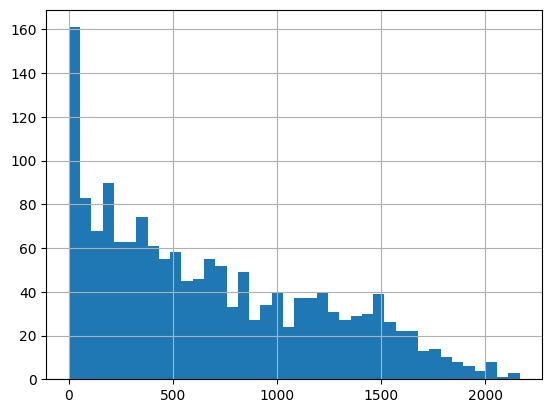

In [35]:
df['delay_days'].hist(bins=40)

# Data's export

## Exportation des femmes n'ayant pas eu de cancer avant l'inclusion (BC and not BC included without time constraints) for all time)

In [36]:
# Enregistre le DataFrame `dataset_breast_cancer_5y_person_df` dans un fichier TSV local
destination_filename = 'df_bc_ko_at_inclusion_361k_nb_BC_WITHIN_5Y.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data/"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./df_bc_ko_at_inclusion_361k_nb_BC_WITHIN_5Y.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 34.0 MiB]                                                \r-\r- [0 files][  2.1 MiB/ 34.0 MiB]                                                \r\\\r|\r| [0 files][  4.4 MiB/ 34.0 MiB]                                                \r/\r/ [0 files][  6.4 MiB/ 34.0 MiB]                                                \r-\r\\\r\\ [0 files][  8.2 MiB/ 34.0 MiB]                                                \r|\r| [0 files][ 10.0 MiB/ 34.0 MiB]                                                \r/\r-\r- [0 files][ 11.9 MiB/ 34.0 MiB]                                                \r\\\r\\ [0 files][ 13.7 MiB/ 34.0 MiB]                                                \r|\r| [0 files][ 15.5 MiB/ 34.0 MiB]                                                \r/\r-\r- [0 files][ 17.3 MiB/ 34.0 MiB]                                                \r\\\r\\ [0 files][ 19.1 Mi

## Liste des femmes ayant déclaré un cancer après l'inclusion (sans contraintes de temps)

In [37]:
# Enregistre le DataFrame `dataset_breast_cancer_5y_person_df` dans un fichier TSV local
destination_filename = 'list_id_bc_in_all_time_bc_ko_at_inclusion_nb_BC_WITHIN_5Y.txt'
pd.DataFrame(list_id_bc_in_all_time).to_csv(destination_filename, index=False, header=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data/"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./list_id_bc_in_all_time_bc_ko_at_inclusion_nb_BC_WITHIN_5Y.txt [Content-Type=text/plain]...\n/ [0 files][    0.0 B/ 12.4 KiB]                                                \r/ [1 files][ 12.4 KiB/ 12.4 KiB]                                                \r\nOperation completed over 1 objects/12.4 KiB.                                     \n'

## Liste des femmes ayant déclaré un cancer dans les 5 ans après l'inclusion

In [38]:
# Enregistre le DataFrame `dataset_breast_cancer_5y_person_df` dans un fichier TSV local
destination_filename = 'list_id_bc_in_5y_bc_ko_at_inclusion_nb_BC_WITHIN_5Y.txt'
pd.DataFrame(list_id_bc_in_5y).to_csv(destination_filename, index=False, header=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data/"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./list_id_bc_in_5y_bc_ko_at_inclusion_nb_BC_WITHIN_5Y.txt [Content-Type=text/plain]...\n/ [0 files][    0.0 B/ 12.2 KiB]                                                \r/ [1 files][ 12.2 KiB/ 12.2 KiB]                                                \r\nOperation completed over 1 objects/12.2 KiB.                                     \n'

## Exportation de toutes les femmes ayant eu un cancer du sein

In [39]:
# Enregistre le DataFrame `df_issues` dans un fichier TSV local
destination_filename = 'df_bc_10k_nb_BC_WITHIN_5Y.tsv'
df_issues.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data/"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./df_bc_10k_nb_BC_WITHIN_5Y.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 1010 KiB]                                                \r/ [1 files][ 1010 KiB/ 1010 KiB]                                                \r-\r\nOperation completed over 1 objects/1010.6 KiB.                                   \n'